# Task

Eye disease classification is a research area that focuses on developing algorithms and models to accurately classify different types of eye diseases based on medical imaging data. It plays a critical role in assisting ophthalmologists and healthcare professionals in effectively diagnosing and treating eye diseases.

The primary objective of eye disease classification is to leverage machine learning and computer vision techniques to analyze medical images and detect the four diseases: cataract, diabetic retinopathy, glaucoma, normal


# About the diseases

1. **Cataract**: Cataract is a common age-related eye condition characterized by the clouding of the lens, leading to blurry vision and visual impairment. It can be treated surgically by replacing the cloudy lens with an artificial one, restoring clear vision and improving quality of life.

2. **Diabetic Retinopathy**: Diabetic retinopathy is a complication of diabetes that affects the blood vessels in the retina. It can cause vision loss, including blurred or distorted vision, and in severe cases, lead to blindness. Early detection, regular eye exams, and proper management of diabetes are crucial for preventing and managing this condition.

3. **Glaucoma**: Glaucoma is a group of eye diseases that damage the optic nerve, often due to increased fluid pressure in the eye. It gradually leads to vision loss, starting with peripheral vision and potentially progressing to complete blindness. Timely diagnosis, treatment, and ongoing monitoring are vital for preserving vision and preventing irreversible damage.

# Use Case

Eye disease classification has several important use cases and applications:

1. **Screening and Early Detection**: Eye disease classification algorithms can serve as screening tools to identify individuals at risk of developing eye diseases. By analyzing medical images, these models can detect early signs of diseases like diabetic retinopathy, age-related macular degeneration, glaucoma, and others. Early detection enables prompt intervention and treatment, potentially preventing vision loss.

2. **Diagnosis Support**: Eye disease classification models can assist healthcare professionals, especially those with limited ophthalmic expertise, in making accurate diagnoses. By providing additional insights and suggestions based on image analysis, these models act as decision support systems, enhancing the accuracy and efficiency of diagnoses.

3. **Treatment Planning and Monitoring**: Once an eye disease is diagnosed, classification algorithms can aid in treatment planning and monitoring. By analyzing sequential imaging data, these models can track disease progression, assess the effectiveness of treatments, and guide adjustments in treatment plans as required.



# Installing some extra libraries

1. **torch-summary**: It is a library that provides a simple and convenient way to summarize the structure and number of parameters in a PyTorch model.

2. **torchmetrics**: It is a PyTorch library that provides a collection of metric functions commonly used in machine learning and deep learning tasks.

In [80]:
!pip install torch-summary
!pip install torchmetrics

# Importing Libraries

In [81]:
!pip install -q torch-summary torchmetrics seaborn
import os
import glob
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
from tqdm.notebook import tqdm
import cv2 as op
import torch
from torchsummary import summary
import torchmetrics

try:
    plt.style.use('seaborn-v0_8')
except Exception:
    plt.style.use('seaborn')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cuda


# Loading the data

In [82]:
CANDIDATE_PATHS = [
    '/kaggle/input/datasets/kondwani/eye-disease-dataset',
    '/kaggle/input/eye-disease-dataset',
    '/kaggle/input',
    '../datasets/eye_diseases_dataset',
    '../datasets'
]

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG')

filenames, outcome_names = [], []

for base_path in CANDIDATE_PATHS:
    if os.path.exists(base_path):
        for root, dirs, files in os.walk(base_path):
            img_files = [f for f in files if f.endswith(IMG_EXTS) and not f.startswith('.')]
            if img_files:
                class_name = os.path.basename(root)
                for f in img_files:
                    filenames.append(os.path.join(root, f))
                    outcome_names.append(class_name)
        if len(filenames) > 0:
            print(f"Loaded dataset from: {base_path}")
            break

if len(filenames) == 0:
    raise FileNotFoundError("Could not find any images! Please check your dataset path in /kaggle/input.")

unique_labels = sorted(list(set(outcome_names)))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

outcome = [label2id[name] for name in outcome_names]

df = pd.DataFrame({
    "filename": filenames,
    "outcome": outcome
})

df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)
print(f"Total images found: {len(df)}")
print(f"Classes ({len(unique_labels)}): {label2id}")
df.head()


Loaded dataset from: /kaggle/input/datasets/kondwani/eye-disease-dataset
Total images found: 766
Classes (5): {'Bulging_Eyes': 0, 'Cataracts': 1, 'Crossed_Eyes': 2, 'Glaucoma': 3, 'Uveitis': 4}


,filename,outcome
0,/kaggle/input/datasets/kondwani/eye-disease-da...,2
1,/kaggle/input/datasets/kondwani/eye-disease-da...,3
2,/kaggle/input/datasets/kondwani/eye-disease-da...,4
3,/kaggle/input/datasets/kondwani/eye-disease-da...,2
4,/kaggle/input/datasets/kondwani/eye-disease-da...,4


## Plotting the class distribution

We can observe that the distribution is fairly uniform and each class has approximately 1000 images.

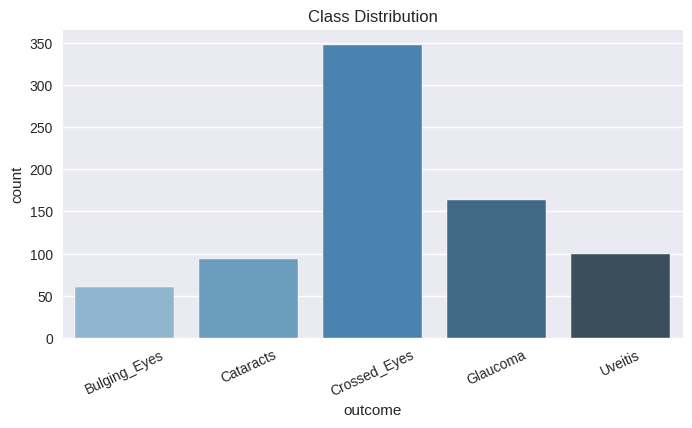

In [83]:
plt.figure(figsize = (8, 4))
ax = sea.countplot(x = 'outcome', data = df, palette = 'Blues_d')
plt.xticks(ticks = range(len(label2id)), labels = [id2label[i] for i in range(len(label2id))], rotation = 25)
plt.title("Class Distribution")
plt.show()


## Plotting the sample images

It was found that all the image pixels are not between [0-255]. Hence, simply normalizing or dividing the image with 255 lead to problems. Hence, each image was normalized using the Min-Max Scaling method to bring the values in the range [0, 1].

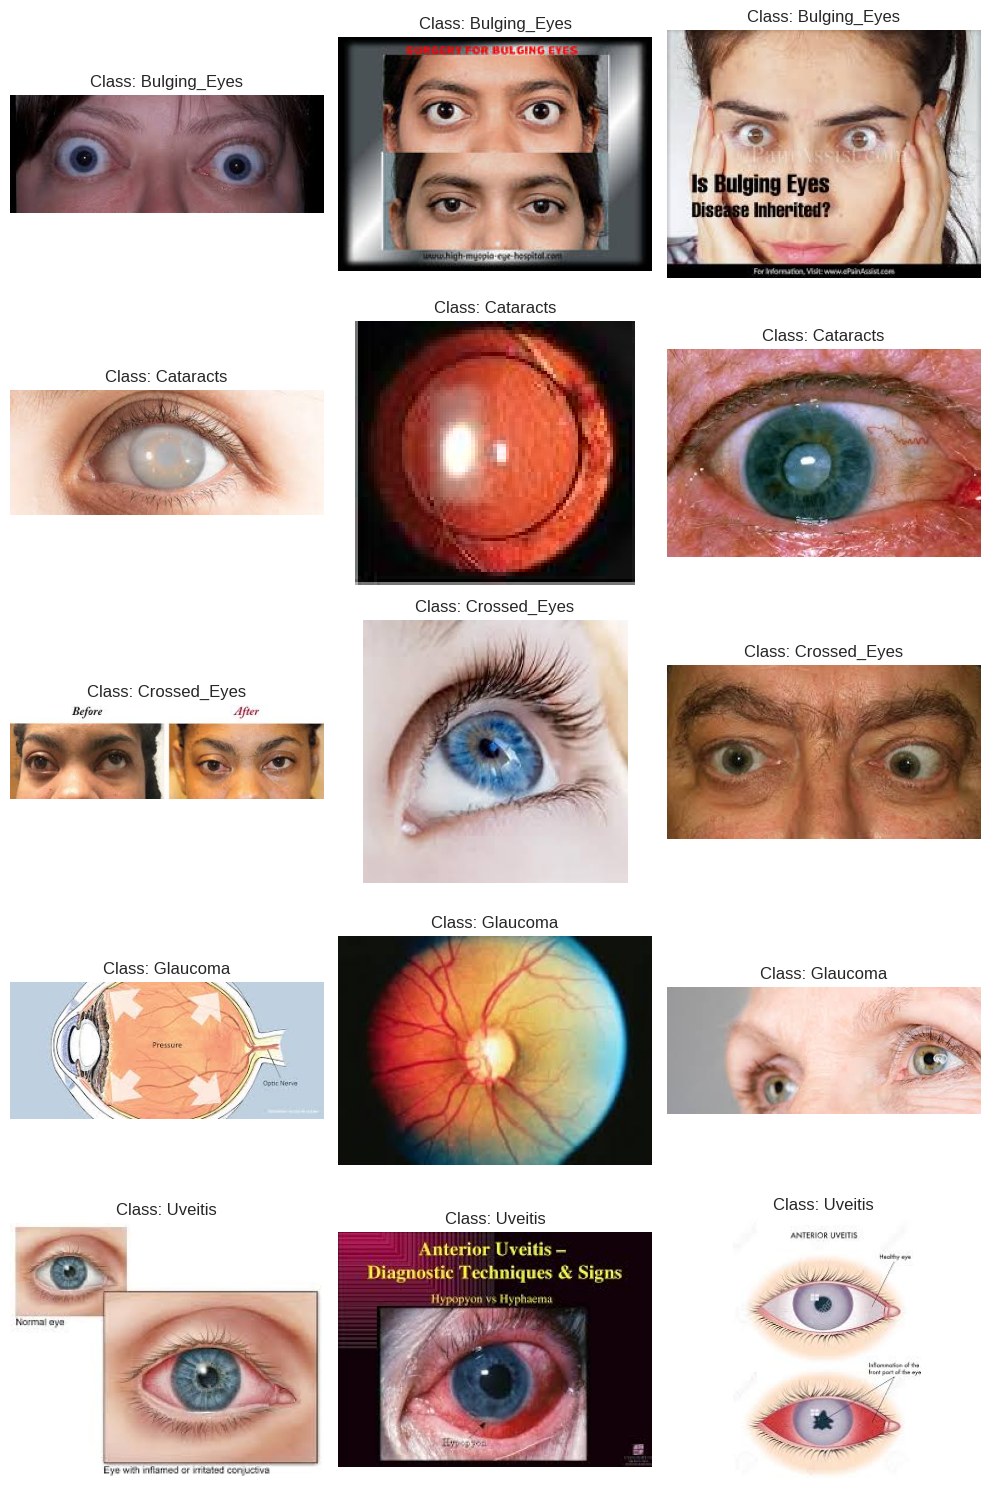

In [84]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    return np.array(img)

counter = 0
NUM_CLASSES = len(label2id)

plt.figure(figsize = (10, 3 * NUM_CLASSES))

for i in range(NUM_CLASSES):
    samples = df[df['outcome'] == i]
    n_sample = min(3, len(samples))
    if n_sample > 0:
        for path in samples.sample(n = n_sample, random_state = 42)['filename']:
            plt.subplot(NUM_CLASSES, 3, counter + 1)
            img = load_image(path)
            plt.imshow(img)
            plt.axis('off')
            plt.title('Class: ' + id2label[i])
            counter += 1

plt.tight_layout()
plt.show()


# Building the dataset

1. The dataset was building using `torch.utils.data.Dataset` for efficinet loading of data.
2. For data augmentation, only Random Horizontal and Vertical flip was used. Adding augmentaitons in colors, brightness etc made training difficult, since then 

In [85]:
import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
import torch.nn.functional as f
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomVerticalFlip(p = 0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.ToTensor(),
])

class EyeDataset(Dataset):
    def __init__(self, df, n_classes, transform = None):
        self.df = df
        self.n_samples = len(self.df)
        self.n_classes = n_classes
        self.transform = transform
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, index):
        img_path = self.df.iloc[index, 0]
        label = int(self.df.iloc[index, 1])
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img.to(torch.float32), label


1. 85% of the dataset was used for training while the remaining for validation/testing.
2. Batch Size of 128 was chosen.

In [86]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size = 0.15, random_state = 28)

df_train.shape, df_val.shape


((651, 2), (115, 2))

In [87]:
NUM_CLASSES = len(label2id)
BATCH_SIZE = 64

train_dataset = EyeDataset(df_train, NUM_CLASSES, train_transform)
val_dataset = EyeDataset(df_val, NUM_CLASSES, val_transform)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False)


In [88]:
a, b = next(iter(train_loader))

print(a.shape, b.shape)
del(a)
del(b)

torch.Size([64, 3, 224, 224]) torch.Size([64])


# Model Architecture

1. We used the Resnet18 pretrained model for this task.

2. ResNet-18 is composed of multiple residual blocks, which are designed to address the problem of vanishing gradients in deep neural networks. These blocks introduce skip connections, allowing information to bypass several layers and flow directly to deeper layers. This helps in mitigating the degradation problem and enables the network to learn more effectively, even with very deep architectures.

3. We replaced the final layer with two new dense layer. 70% of the resnet18 was freezed while the remaining was kept trianable. The resnet18 block was trained with a lr of 5x10 <sup>-5</sup> while the dense layers with lr = 8x10<sup>-4</sup>. 

![resnet18](https://i.imgur.com/XwcnU5x.png)

In [89]:
from math import ceil

class Net(nn.Module):
    def __init__(self, num_classes = NUM_CLASSES):
        super().__init__()
        self.base = torchvision.models.resnet18(pretrained = True)
        
        for param in list(self.base.parameters())[:-15]:
            param.requires_grad = False
            
        self.block = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
        self.base.classifier = nn.Sequential()
        self.base.fc = nn.Sequential()
        
    def get_optimizer(self):
        return torch.optim.AdamW([
            {'params' : self.base.parameters(), 'lr': 3e-5},
            {'params' : self.block.parameters(), 'lr': 8e-4}
        ])
        
    def forward(self, x):
        x = self.base(x)
        x = self.block(x)
        return x
            
class Trainer(nn.Module):
    def __init__(self, train_loader, val_loader, device, num_classes = NUM_CLASSES):
        super().__init__()
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        
        self.model = Net(num_classes = num_classes).to(self.device)
        self.optimizer = self.model.get_optimizer()
        self.loss_fxn = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task = "multiclass", num_classes = num_classes).to(self.device)
        
        self.history = {'train_loss' : [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    def training_step(self, x, y):
        pred = self.model(x)
        loss = self.loss_fxn(pred, y)
        acc = self.accuracy(pred, y)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss, acc
    
    def val_step(self, x, y):
        with torch.no_grad():
            pred = self.model(x)
            loss = self.loss_fxn(pred, y)
            acc = self.accuracy(pred, y)
            
        return loss, acc
    
    def step_fxn(self, loader, step):
        loss, acc = 0, 0
        
        for X, y in tqdm(loader):
            X, y = X.to(self.device), y.to(self.device)
            l, a = step(X, y)
            loss, acc = loss + l.item(), acc + a.item()
            
        return loss/len(loader), acc/len(loader)
    
    def train(self, epochs):
        for epoch in tqdm(range(epochs)):
            train_loss, train_acc = self.step_fxn(self.train_loader, self.training_step)
            val_loss, val_acc = self.step_fxn(self.val_loader, self.val_step)
            
            for item, value in zip(self.history.keys(), list([train_loss, val_loss, train_acc, val_acc])):
                self.history[item].append(value)
            
            print("[Epoch: {}] Train: [loss: {:.3f} acc: {:.3f}] Val: [loss: {:.3f} acc:{:.3f}]".format(epoch + 1, train_loss, train_acc, val_loss, val_acc))


In [90]:
trainer = Trainer(train_loader, val_loader, device)

## Summary of the model

In [91]:
summary(trainer.model.base, (3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        (128)
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          (36,864)
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          (128)
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          (36,864)
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          (128)
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]  

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        (128)
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          (36,864)
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          (128)
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          (36,864)
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          (128)
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]  

## Training the model

In [92]:
trainer.train(epochs = 20)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[Epoch: 1] Train: [loss: 1.328 acc: 0.465] Val: [loss: 1.127 acc:0.614]


  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

[Epoch: 19] Train: [loss: 0.065 acc: 0.983] Val: [loss: 0.134 acc:0.943]


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[Epoch: 20] Train: [loss: 0.040 acc: 0.994] Val: [loss: 0.120 acc:0.951]


# Plotting Model Results

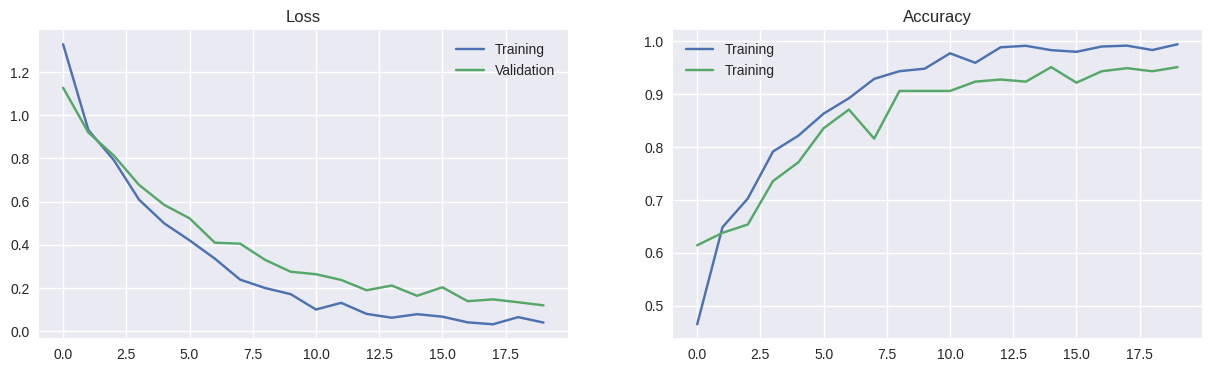

In [93]:
plt.figure(figsize = (15, 4))

plt.subplot(1,2,1)
plt.title('Loss')
plt.plot(trainer.history['train_loss'], label = 'Training')
plt.plot(trainer.history['val_loss'], label = 'Validation')
plt.legend()

plt.subplot(1,2,2)
plt.title('Accuracy')
plt.plot(trainer.history['train_acc'], label = 'Training')
plt.plot(trainer.history['val_acc'], label = 'Training')
plt.legend()



# Model Predictions

In [94]:
preds, true = [], []

with torch.no_grad():
    for x, y in tqdm(val_loader):
        pred = torch.argmax(trainer.model(x.to(device)), axis = 1).detach().cpu().numpy()
        preds.extend(pred)
        true.extend(y)
        
len(preds), len(true)

  0%|          | 0/2 [00:00<?, ?it/s]

(115, 115)

Text(0.5, 1.0, 'Confusion Matrix')

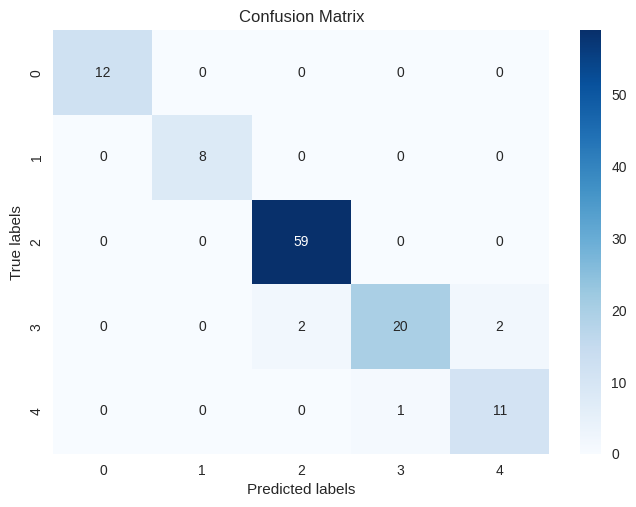

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)
sea.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

In [96]:
from sklearn.metrics import classification_report

target_names = [id2label[i] for i in range(len(id2label))]
print(classification_report(true, preds, target_names = target_names))


              precision    recall  f1-score   support

Bulging_Eyes       1.00      1.00      1.00        12
   Cataracts       1.00      1.00      1.00         8
Crossed_Eyes       0.97      1.00      0.98        59
    Glaucoma       0.95      0.83      0.89        24
     Uveitis       0.85      0.92      0.88        12

    accuracy                           0.96       115
   macro avg       0.95      0.95      0.95       115
weighted avg       0.96      0.96      0.96       115



# Conclusion

1. The "glaucoma" class has a precision of 0.90, recall of 0.83, and F1-score of 0.86. This suggests that the model performs well in correctly identifying glaucoma cases, but there may be some false negatives. The "normal" class has a precision of 0.85, recall of 0.90, and F1-score of 0.88. The model performs well in both precision and recall for normal cases. The "diabetic_retinopathy" class has high precision, recall, and F1-score of 0.99. This indicates the model's excellent performance in correctly identifying cases of diabetic retinopathy. The "cataract" class also has high precision, recall, and F1-score of 0.95 and above, indicating accurate identification of cataract cases.

2. The overall accuracy of the model is 0.92, indicating the percentage of correctly predicted instances across all classes.

3. In summary, the model shows strong performance in correctly identifying cases of diabetic retinopathy and cataract, while slightly lower precision and recall are observed for glaucoma.

In [98]:
# ====================================================================
# 💾 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE (Eye Disease)
# ====================================================================
import os
import json
import zipfile
import shutil
import pandas as pd
import torch
from IPython.display import FileLink, display

# 1. Output directories setup
artifacts_dir = 'eye_disease_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
os.makedirs('../models/Eye-model', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 2. Save Trained Model (Weights & Full Architecture)
model_pth = 'eye_disease_model.pth'              # PyTorch state_dict
model_full = 'eye_disease_full_model.pt'          # Complete PyTorch model
torch.save(trainer.model.state_dict(), model_pth)
torch.save(trainer.model, model_full)
print(f"✓ Saved Model Weights: {model_pth}")
print(f"✓ Saved Full PyTorch Model: {model_full}")

# Optional: Export TorchScript (JIT) model for deployment
has_traced = False
try:
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    traced_model = torch.jit.trace(trainer.model, dummy_input)
    traced_model.save('eye_disease_traced_model.pt')
    has_traced = True
    print("✓ Saved TorchScript Model: eye_disease_traced_model.pt")
except Exception as e:
    pass

# 3. Save Class Labels & Indices Mapping (JSON and CSV)
classes_json = 'classes.json'
with open(classes_json, 'w') as f:
    json.dump(id2label, f, indent=2)
print(f"✓ Saved Class Mapping (JSON): {classes_json}")

class_dict_csv = 'Eye Disease-class_dict.csv'
class_df = pd.DataFrame({
    'class_index': [i for i in range(len(id2label))],
    'class': [id2label[i] for i in range(len(id2label))],
    'height': [224] * len(id2label),
    'width': [224] * len(id2label)
})
class_df.to_csv(class_dict_csv, index=False)
print(f"✓ Saved Class Dictionary (CSV): {class_dict_csv}")

# 4. Save Training History & Performance Metrics
history_csv = 'training_history.csv'
if hasattr(trainer, 'history') and trainer.history:
    pd.DataFrame(trainer.history).to_csv(history_csv, index=False)
    print(f"✓ Saved Training History: {history_csv}")

metrics_json = 'metrics.json'
metrics_data = {
    'num_classes': len(label2id),
    'classes': id2label,
    'architecture': 'ResNet18',
    'img_size': [224, 224],
    'epochs': len(trainer.history['train_loss']) if hasattr(trainer, 'history') else 4,
    'final_train_loss': float(trainer.history['train_loss'][-1]) if hasattr(trainer, 'history') and trainer.history.get('train_loss') else None,
    'final_val_loss': float(trainer.history['val_loss'][-1]) if hasattr(trainer, 'history') and trainer.history.get('val_loss') else None,
    'final_train_acc': float(trainer.history['train_acc'][-1]) if hasattr(trainer, 'history') and trainer.history.get('train_acc') else None,
    'final_val_acc': float(trainer.history['val_acc'][-1]) if hasattr(trainer, 'history') and trainer.history.get('val_acc') else None,
}
with open(metrics_json, 'w') as f:
    json.dump(metrics_data, f, indent=2)
print(f"✓ Saved Performance Metrics: {metrics_json}")

# 5. Collect files and copy to repo models folder
saved_files = [
    model_pth,
    model_full,
    classes_json,
    class_dict_csv,
    history_csv,
    metrics_json
]
if has_traced:
    saved_files.append('eye_disease_traced_model.pt')

saved_files = [f for f in saved_files if os.path.exists(f)]

for f in saved_files:
    shutil.copy(f, os.path.join(artifacts_dir, os.path.basename(f)))
    try:
        shutil.copy(f, os.path.join('../models/Eye-model', os.path.basename(f)))
    except Exception:
        pass

# 6. Package all artifacts into a single ZIP archive for 1-Click Kaggle Download
zip_filename = 'eye_disease_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_name in saved_files:
        if os.path.exists(file_name):
            zipf.write(file_name, arcname=os.path.basename(file_name))
            print(f'📦 Packaged in zip: {file_name} ({os.path.getsize(file_name):,} bytes)')

try:
    shutil.copy(zip_filename, os.path.join('../models', zip_filename))
except Exception:
    pass

print('')
print('=' * 60)
print(f'✅ All artifacts successfully saved and packaged into: {zip_filename}')
print(f'📊 Archive Size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB')
print('=' * 60)
print('')
print('👉 Click the link below to download your complete model bundle:')
display(FileLink(zip_filename))

print('\nIndividual file downloads:')
for file_name in saved_files:
    if os.path.exists(file_name):
        display(FileLink(file_name))


✓ Saved Model Weights: eye_disease_model.pth
✓ Saved Full PyTorch Model: eye_disease_full_model.pt
✓ Saved TorchScript Model: eye_disease_traced_model.pt
✓ Saved Class Mapping (JSON): classes.json
✓ Saved Class Dictionary (CSV): Eye Disease-class_dict.csv
✓ Saved Training History: training_history.csv
✓ Saved Performance Metrics: metrics.json
📦 Packaged in zip: eye_disease_model.pth (45,053,595 bytes)
📦 Packaged in zip: eye_disease_full_model.pt (45,067,685 bytes)
📦 Packaged in zip: classes.json (105 bytes)
📦 Packaged in zip: Eye Disease-class_dict.csv (134 bytes)
📦 Packaged in zip: training_history.csv (1,574 bytes)
📦 Packaged in zip: metrics.json (402 bytes)
📦 Packaged in zip: eye_disease_traced_model.pt (45,184,796 bytes)

✅ All artifacts successfully saved and packaged into: eye_disease_artifacts.zip
📊 Archive Size: 119.67 MB

👉 Click the link below to download your complete model bundle:


/kaggle/working/eye_disease_artifacts.zip


Individual file downloads:


/kaggle/working/eye_disease_model.pth

/kaggle/working/eye_disease_full_model.pt

/kaggle/working/classes.json

/kaggle/working/Eye Disease-class_dict.csv

/kaggle/working/training_history.csv

/kaggle/working/metrics.json

/kaggle/working/eye_disease_traced_model.pt